<a href="https://colab.research.google.com/github/ST3ALT4/ucs547/blob/main/Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

path = kagglehub.dataset_download(
    "alihasnainch/fruits-dataset-for-classification"
)

print("Dataset Path:", path)

100%|██████████| 14.5M/14.5M [00:00<00:00, 65.1MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/alihasnainch/fruits-dataset-for-classification/versions/1


In [3]:
import os

image_files = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_files.append(os.path.join(root, file))

print("Total Images Found:", len(image_files))

image_files = image_files[:1655]

print("Images selected:", len(image_files))

Total Images Found: 1655
Images selected: 1655


In [4]:
import cv2
import time
import numpy as np

cpu_times = []

start_total = time.time()

for img_path in image_files:

    start = time.time()

    img = cv2.imread(img_path)

    resized = cv2.resize(img, (512, 512))

    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    end = time.time()

    cpu_times.append(end - start)

cpu_total_time = time.time() - start_total
cpu_avg_time = np.mean(cpu_times)

print("CPU Total Time:", cpu_total_time)
print("CPU Avg Time/Image:", cpu_avg_time)

CPU Total Time: 3.9944159984588623
CPU Avg Time/Image: 0.0024107839405716727


In [5]:
!apt-get update
!apt-get install -y build-essential
!apt-get install -y cuda-toolkit-12-1

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [91.2 kB]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelea

In [6]:
!git clone https://github.com/UsingNet/nvjpeg-python.git

Cloning into 'nvjpeg-python'...
remote: Enumerating objects: 238, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 238 (delta 21), reused 20 (delta 20), pack-reused 208 (from 1)
Receiving objects: 100% (238/238), 405.47 KiB | 9.01 MiB/s, done.
Resolving deltas: 100% (123/123), done.


In [7]:
%cd nvjpeg-python

!python setup.py install

/content/nvjpeg-python
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:66: SetuptoolsDeprecationWarning: setup.py install is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` directly.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https://blog.ganssle.io/articles/2021/10/setup-py-deprecated.html for details.
        ********************************************************************************

!!
  self.initialize_options()
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:66: EasyInstallDeprecationWarning: easy_install command is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` and ``easy_install``.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        Se

In [8]:
from nvjpeg import NvJpeg

nj = NvJpeg()

print("nvJPEG initialized successfully")

nvJPEG initialized successfully


In [9]:
from nvjpeg import NvJpeg
import cupy as cp
import cv2
import time
import numpy as np

nj = NvJpeg()

gpu_times = []

gpu_total_start = time.time()

for img_path in image_files:

    start = time.time()

    img = nj.read(img_path)

    gpu_img = cp.asarray(img)

    resized_cpu = cv2.resize(
        cp.asnumpy(gpu_img),
        (512, 512)
    )

    resized_gpu = cp.asarray(resized_cpu)

    gray_gpu = (
        0.299 * resized_gpu[:, :, 2] +
        0.587 * resized_gpu[:, :, 1] +
        0.114 * resized_gpu[:, :, 0]
    )

    result = cp.asnumpy(gray_gpu).astype(np.uint8)

    end = time.time()

    gpu_times.append(end - start)

gpu_total_time = time.time() - gpu_total_start
gpu_avg_time = np.mean(gpu_times)

print("GPU Total Time:", gpu_total_time)
print("GPU Avg Time:", gpu_avg_time)

GPU Total Time: 6.470823287963867
GPU Avg Time: 0.0039061088216268765


In [10]:
speedup = cpu_total_time / gpu_total_time

print("Speedup:", speedup)

Speedup: 0.6172964120174204


In [11]:
import pandas as pd

results = pd.DataFrame({
    "Pipeline": ["CPU", "GPU (nvJPEG)"],
    "Total Time": [cpu_total_time, gpu_total_time],
    "Average Time/Image": [cpu_avg_time, gpu_avg_time]
})

results

,Pipeline,Total Time,Average Time/Image
0,CPU,3.994416,0.002411
1,GPU (nvJPEG),6.470823,0.003906


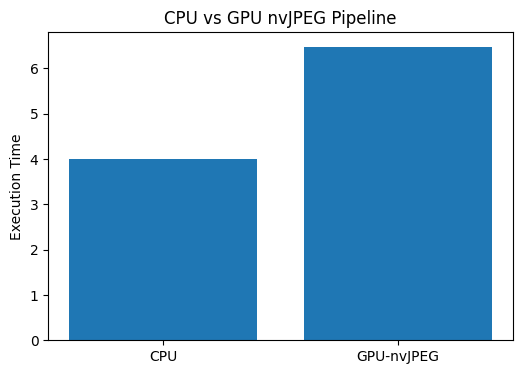

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    ["CPU", "GPU-nvJPEG"],
    [cpu_total_time, gpu_total_time]
)

plt.ylabel("Execution Time")
plt.title("CPU vs GPU nvJPEG Pipeline")

plt.show()

# Question 2

In [13]:
import os

image_files = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_files.append(os.path.join(root, file))

print("Images Found:", len(image_files))

img_path = image_files[0]

print("Selected Image:", img_path)

Images Found: 1655
Selected Image: /root/.cache/kagglehub/datasets/alihasnainch/fruits-dataset-for-classification/versions/1/fresh_strawberries_done/fresh_strawberry_3.jpg


In [14]:
from nvjpeg import NvJpeg
import cupy as cp
import numpy as np

nj = NvJpeg()

# Decode JPEG
img = nj.read(img_path)

print("Image Shape:", img.shape)

Image Shape: (300, 300, 3)


In [15]:
import cv2

resolutions = [
    (256, 256),
    (1024, 1024)
]

In [16]:
direct_results = []

for size in resolutions:

    resized = cv2.resize(img, size)

    gray_direct = cv2.cvtColor(
        resized,
        cv2.COLOR_BGR2GRAY
    )

    direct_results.append(gray_direct)

print("Direct grayscale completed")

Direct grayscale completed


In [17]:
manual_results = []

for size in resolutions:

    resized = cv2.resize(img, size)

    gpu_img = cp.asarray(resized)

    gray_manual = (
        0.299 * gpu_img[:, :, 2] +
        0.587 * gpu_img[:, :, 1] +
        0.114 * gpu_img[:, :, 0]
    )

    result = cp.asnumpy(gray_manual).astype(np.uint8)

    manual_results.append(result)

print("Manual grayscale completed")

Manual grayscale completed


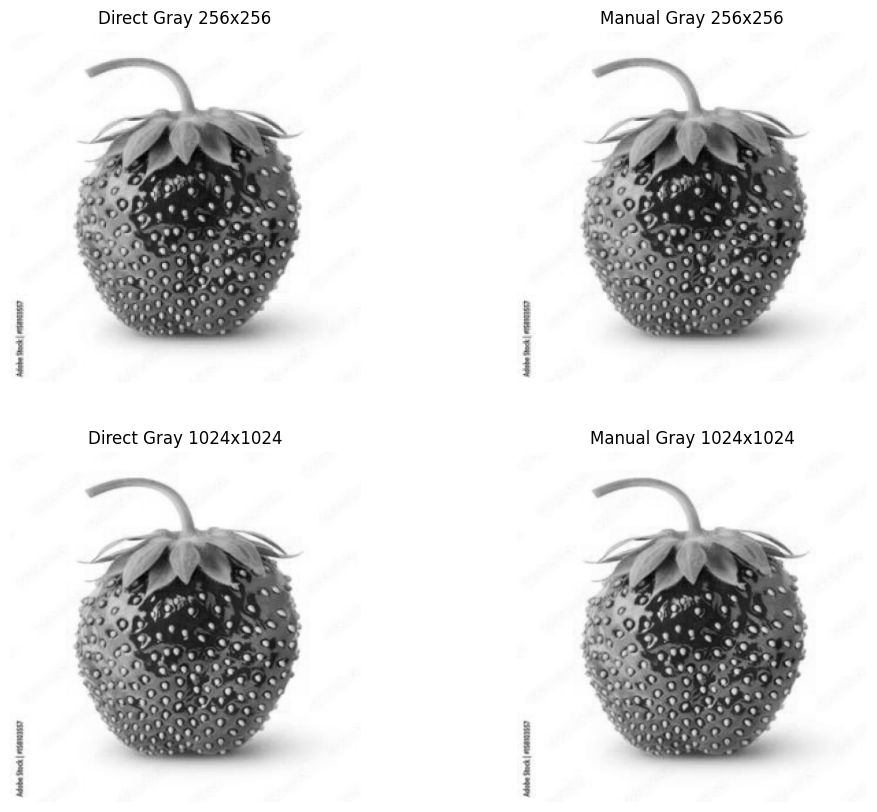

In [18]:
import matplotlib.pyplot as plt

titles = [
    "Direct Gray 256x256",
    "Manual Gray 256x256",
    "Direct Gray 1024x1024",
    "Manual Gray 1024x1024"
]

images = [
    direct_results[0],
    manual_results[0],
    direct_results[1],
    manual_results[1]
]

plt.figure(figsize=(12,10))

for i in range(4):

    plt.subplot(2,2,i+1)

    plt.imshow(images[i], cmap='gray')

    plt.title(titles[i])

    plt.axis("off")

plt.show()

In [19]:
import time

for size in resolutions:

    resized = cv2.resize(img, size)

    start = time.time()

    gray_direct = cv2.cvtColor(
        resized,
        cv2.COLOR_BGR2GRAY
    )

    direct_time = time.time() - start

    start = time.time()

    gpu_img = cp.asarray(resized)

    gray_manual = (
        0.299 * gpu_img[:, :, 2] +
        0.587 * gpu_img[:, :, 1] +
        0.114 * gpu_img[:, :, 0]
    )

    cp.asnumpy(gray_manual)

    manual_time = time.time() - start

    print(f"\nResolution: {size}")
    print("Direct Gray Time:", direct_time)
    print("Manual Gray Time:", manual_time)


Resolution: (256, 256)
Direct Gray Time: 8.0108642578125e-05
Manual Gray Time: 0.0008442401885986328

Resolution: (1024, 1024)
Direct Gray Time: 0.0006377696990966797
Manual Gray Time: 0.003653287887573242


In [20]:
cv2.imwrite("direct_gray_256.jpg", direct_results[0])
cv2.imwrite("manual_gray_256.jpg", manual_results[0])

cv2.imwrite("direct_gray_1024.jpg", direct_results[1])
cv2.imwrite("manual_gray_1024.jpg", manual_results[1])

print("All outputs saved")

All outputs saved


# Question 3

In [21]:
import os

image_files = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_files.append(os.path.join(root, file))

print("Total Images:", len(image_files))

image_files = image_files[:1655]

print("Selected Images:", len(image_files))

Total Images: 1655
Selected Images: 1655


In [22]:
batch_sizes = [8, 16, 32,64,128]

resolutions = [
    (256, 256),
    (512, 512)
]

In [23]:
import cv2
import cupy as cp
import numpy as np
import time

hybrid_results = []

for batch_size in batch_sizes:

    for resolution in resolutions:

        start_total = time.time()

        for i in range(0, len(image_files), batch_size):

            batch = image_files[i:i+batch_size]

            processed = []

            for img_path in batch:

                img = cv2.imread(img_path)

                resized = cv2.resize(img, resolution)

                gpu_img = cp.asarray(resized)

                normalized = gpu_img / 255.0

                processed.append(normalized)

        total_time = time.time() - start_total

        throughput = len(image_files) / total_time

        hybrid_results.append([
            batch_size,
            resolution,
            total_time,
            throughput
        ])

        print(
            f"Hybrid | Batch={batch_size} | "
            f"Resolution={resolution} | "
            f"Time={total_time:.4f} | "
            f"Throughput={throughput:.2f}"
        )

Hybrid | Batch=8 | Resolution=(256, 256) | Time=1.7532 | Throughput=943.99
Hybrid | Batch=8 | Resolution=(512, 512) | Time=2.1766 | Throughput=760.35
Hybrid | Batch=16 | Resolution=(256, 256) | Time=1.3964 | Throughput=1185.20
Hybrid | Batch=16 | Resolution=(512, 512) | Time=2.8125 | Throughput=588.45
Hybrid | Batch=32 | Resolution=(256, 256) | Time=1.6627 | Throughput=995.34
Hybrid | Batch=32 | Resolution=(512, 512) | Time=2.1479 | Throughput=770.53
Hybrid | Batch=64 | Resolution=(256, 256) | Time=1.4216 | Throughput=1164.22
Hybrid | Batch=64 | Resolution=(512, 512) | Time=2.1485 | Throughput=770.30
Hybrid | Batch=128 | Resolution=(256, 256) | Time=1.4049 | Throughput=1178.05
Hybrid | Batch=128 | Resolution=(512, 512) | Time=2.2202 | Throughput=745.43


In [25]:
from nvidia.dali.pipeline import Pipeline
import nvidia.dali.fn as fn
import nvidia.dali.types as types

In [26]:
class DALIPipeline(Pipeline):

    def __init__(
        self,
        batch_size,
        num_threads,
        device_id,
        image_dir,
        resolution
    ):

        super().__init__(
            batch_size,
            num_threads,
            device_id
        )

        self.input = fn.readers.file(
            file_root=image_dir,
            random_shuffle=True
        )

        self.resolution = resolution

    def define_graph(self):

        jpegs, labels = self.input

        images = fn.decoders.image(
            jpegs,
            device="mixed",
            output_type=types.RGB
        )

        resized = fn.resize(
            images,
            resize_x=self.resolution[0],
            resize_y=self.resolution[1]
        )

        normalized = fn.crop_mirror_normalize(
            resized,
            dtype=types.FLOAT,
            output_layout="HWC"
        )

        return normalized

In [27]:
dali_results = []

for batch_size in batch_sizes:

    for resolution in resolutions:

        pipe = DALIPipeline(
            batch_size=batch_size,
            num_threads=2,
            device_id=0,
            image_dir=path,
            resolution=resolution
        )

        pipe.build()

        start_total = time.time()

        iterations = len(image_files) // batch_size

        for _ in range(iterations):

            pipe.run()

        total_time = time.time() - start_total

        throughput = len(image_files) / total_time

        dali_results.append([
            batch_size,
            resolution,
            total_time,
            throughput
        ])

        print(
            f"DALI | Batch={batch_size} | "
            f"Resolution={resolution} | "
            f"Time={total_time:.4f} | "
            f"Throughput={throughput:.2f}"
        )

DALI | Batch=8 | Resolution=(256, 256) | Time=0.6304 | Throughput=2625.37
DALI | Batch=8 | Resolution=(512, 512) | Time=0.4321 | Throughput=3830.50
DALI | Batch=16 | Resolution=(256, 256) | Time=0.6206 | Throughput=2666.94
DALI | Batch=16 | Resolution=(512, 512) | Time=0.4198 | Throughput=3942.49
DALI | Batch=32 | Resolution=(256, 256) | Time=0.4811 | Throughput=3440.25
DALI | Batch=32 | Resolution=(512, 512) | Time=0.4177 | Throughput=3961.96
DALI | Batch=64 | Resolution=(256, 256) | Time=0.9864 | Throughput=1677.86
DALI | Batch=64 | Resolution=(512, 512) | Time=0.7164 | Throughput=2310.12
DALI | Batch=128 | Resolution=(256, 256) | Time=0.7529 | Throughput=2198.05
DALI | Batch=128 | Resolution=(512, 512) | Time=1.1646 | Throughput=1421.12


In [28]:
import pandas as pd

hybrid_df = pd.DataFrame(
    hybrid_results,
    columns=[
        "Batch Size",
        "Resolution",
        "Total Time",
        "Throughput"
    ]
)

dali_df = pd.DataFrame(
    dali_results,
    columns=[
        "Batch Size",
        "Resolution",
        "Total Time",
        "Throughput"
    ]
)

print("\nHybrid Pipeline Results")
display(hybrid_df)

print("\nDALI Pipeline Results")
display(dali_df)


Hybrid Pipeline Results


,Batch Size,Resolution,Total Time,Throughput
0,8,"(256, 256)",1.753188,943.994397
1,8,"(512, 512)",2.176638,760.346959
2,16,"(256, 256)",1.396383,1185.204879
3,16,"(512, 512)",2.812497,588.445043
4,32,"(256, 256)",1.662740,995.344895
5,32,"(512, 512)",2.147877,770.528387
6,64,"(256, 256)",1.421550,1164.221928
7,64,"(512, 512)",2.148517,770.298893
8,128,"(256, 256)",1.404868,1178.046315
9,128,"(512, 512)",2.220198,745.429039



DALI Pipeline Results


,Batch Size,Resolution,Total Time,Throughput
0,8,"(256, 256)",0.630388,2625.365159
1,8,"(512, 512)",0.432058,3830.503387
2,16,"(256, 256)",0.620562,2666.939109
3,16,"(512, 512)",0.419785,3942.494159
4,32,"(256, 256)",0.481069,3440.252598
5,32,"(512, 512)",0.417722,3961.960738
6,64,"(256, 256)",0.986374,1677.863129
7,64,"(512, 512)",0.716412,2310.122239
8,128,"(256, 256)",0.752939,2198.054662
9,128,"(512, 512)",1.164571,1421.124407


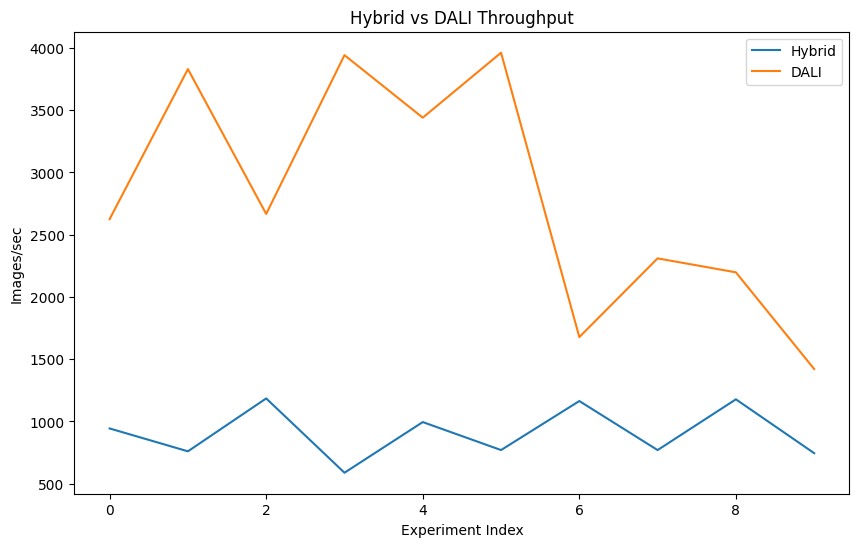

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    hybrid_df["Throughput"],
    label="Hybrid"
)

plt.plot(
    dali_df["Throughput"],
    label="DALI"
)

plt.xlabel("Experiment Index")
plt.ylabel("Images/sec")
plt.title("Hybrid vs DALI Throughput")

plt.legend()

plt.show()

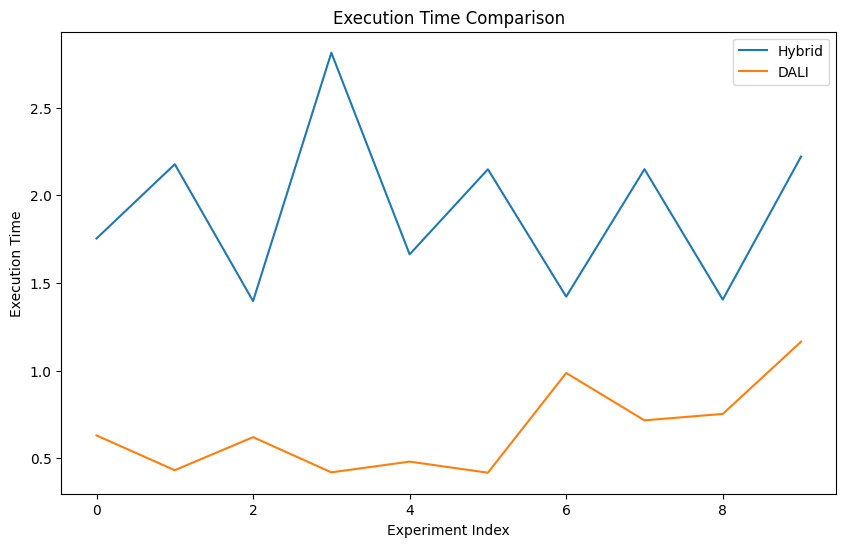

In [30]:
plt.figure(figsize=(10,6))

plt.plot(
    hybrid_df["Total Time"],
    label="Hybrid"
)

plt.plot(
    dali_df["Total Time"],
    label="DALI"
)

plt.xlabel("Experiment Index")
plt.ylabel("Execution Time")
plt.title("Execution Time Comparison")

plt.legend()

plt.show()

In [31]:
hybrid_df.to_csv("hybrid_results.csv", index=False)
dali_df.to_csv("dali_results.csv", index=False)

print("Results saved")

Results saved
